# Recreate reconstruction plots

This notebook loads the compressed `.npz` example data saved by the training script (the file named like `rnn_recon_v4_epoch{N}_final_examples.npz`) and recreates the consolidated and zoomed plots. Edit the `NPZ_PATH` below to point to your output directory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

plt.rcParams.update({'font.size': 12})

In [3]:
# Path to the .npz produced by `plot_reconstruction_examples`
# Update this path if you used a different output_dir.
NPZ_PATH = Path('../tmp_mc_train_test_trunc2048/rnn_recon_v4_epoch3_final_examples.npz')
print('Looking for', NPZ_PATH)
if not NPZ_PATH.exists():
    print('File not found:', NPZ_PATH)
else:
    data = np.load(str(NPZ_PATH))
    print('Found keys:', list(data.keys()))
    for k in data.files:
        print(k, data[k].shape)

Looking for ../tmp_mc_train_test_trunc2048/rnn_recon_v4_epoch3_final_examples.npz
Found keys: ['target', 'recon_mean', 'recon_sigma', 'flux_err', 'mask', 'timestamps', 'samples']
target (4, 2048)
recon_mean (4, 2048)
recon_sigma (4, 2048)
flux_err (4, 2048)
mask (4, 2048)
timestamps (4, 2048)
samples (3, 4, 2048)


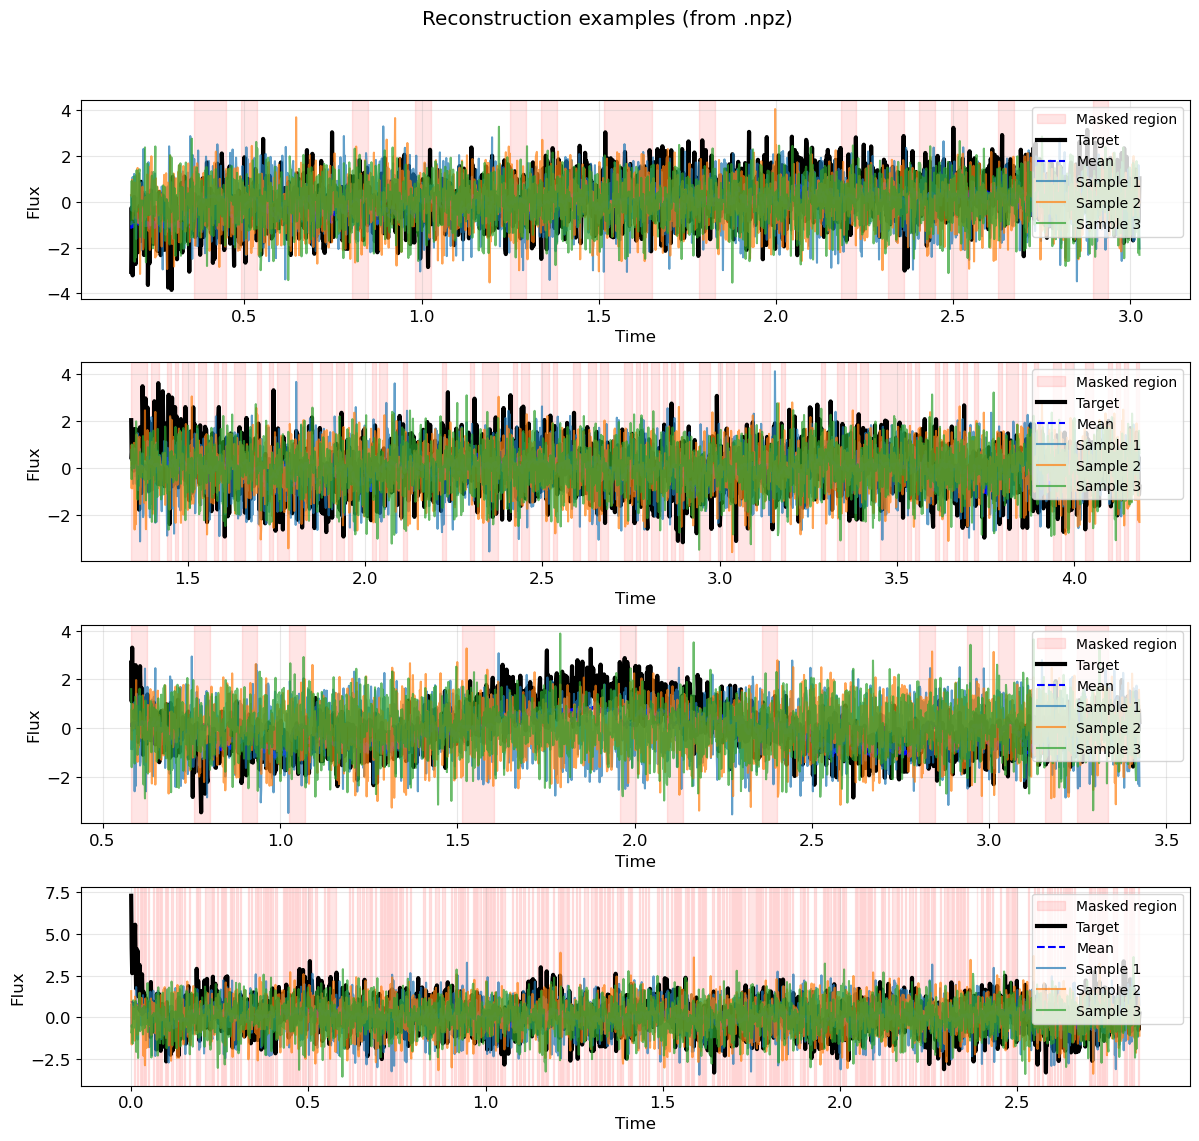

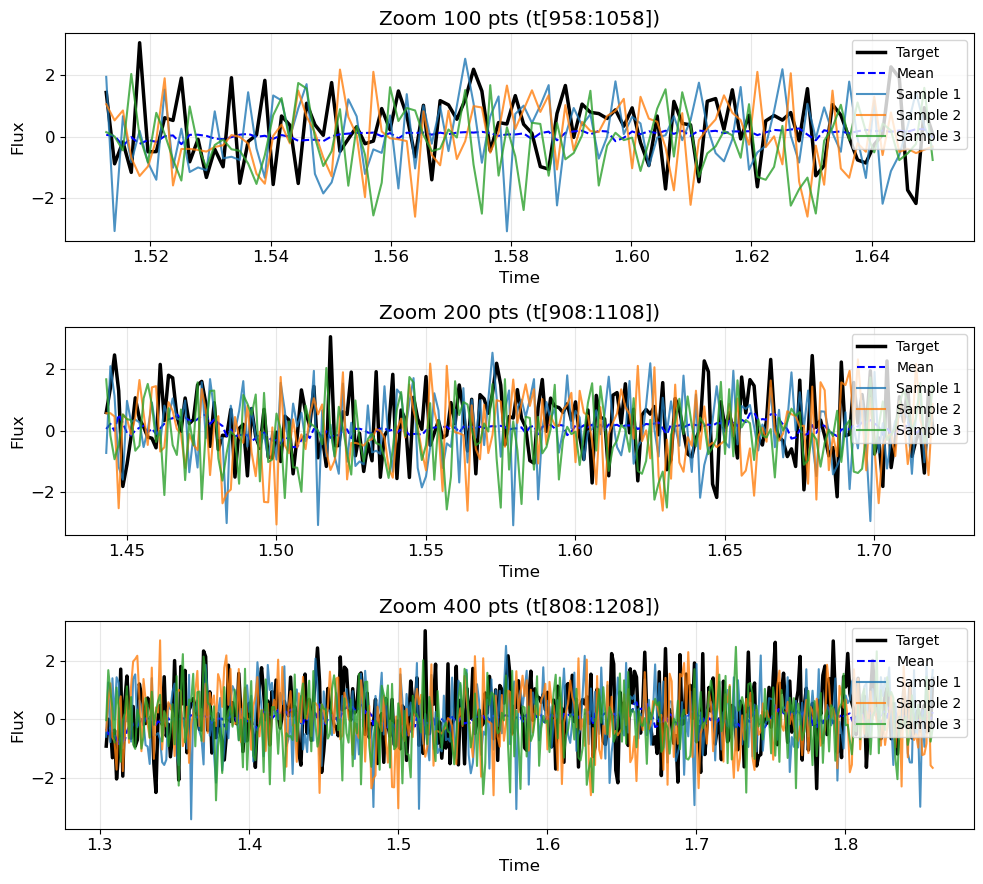

In [ ]:
# Basic reproducer: consolidated plot for up to n_examples and a zoom panel.
def plot_consolidated(data, n_examples=4, num_samples=3, title_suffix='', show=True, save_path=None):
    target = data['target']
    recon_mean = data['recon_mean']
    recon_sigma = data['recon_sigma']
    mask = data['mask']
    timestamps = data['timestamps']
    samples = data['samples']  # shape (num_samples, n_examples, seq_len)

    n_examples = min(n_examples, target.shape[0])
    fig, axes = plt.subplots(n_examples, 1, figsize=(12, 3 * n_examples))
    if n_examples == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        t = timestamps[i]
        tar = target[i]
        mean = recon_mean[i]
        sigma = recon_sigma[i]
        m = mask[i].astype(bool)

        # Shade masked segments
        def shade_regions(ax, t, mask_bool):
            n = len(mask_bool)
            if n == 0:
                return
            cur = mask_bool[0]
            start = 0
            labeled_mask = False
            for idx in range(1, n):
                if mask_bool[idx] != cur:
                    if cur:
                        ax.axvspan(float(t[start]), float(t[idx]), color='red', alpha=0.10, zorder=0, label='Masked region' if not labeled_mask else None)
                        labeled_mask = True
                    start = idx
                    cur = mask_bool[idx]
            if cur:
                ax.axvspan(float(t[start]), float(t[-1]), color='red', alpha=0.10, zorder=0, label='Masked region' if not labeled_mask else None)

        shade_regions(ax, t, m)
        ax.plot(t, tar, color='k', linewidth=3.0, label='Target')
        ax.plot(t, mean, 'b--', linewidth=1.5, label='Mean')

        for s in range(min(num_samples, samples.shape[0])):
            ax.plot(t, samples[s, i], alpha=0.7, label=f'Sample {s+1}')

        ax.set_xlabel('Time')
        ax.set_ylabel('Flux')
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'Reconstruction examples {title_suffix}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    if show:
        plt.show()
    plt.close()

# Zoomed view helper (centered on largest masked segment if present)
def plot_zoom_panels(data, example_idx=0, window_lengths=(100,200,400), num_samples=3, show=True, save_path=None):
    timestamps = data['timestamps'][example_idx]
    mean = data['recon_mean'][example_idx]
    sigma = data['recon_sigma'][example_idx]
    target = data['target'][example_idx]
    mask = data['mask'][example_idx].astype(bool)
    samples = data['samples'][:, example_idx]
    seq_len = target.shape[0]

    # find center of longest masked run
    best_start = None
    best_end = None
    best_len = 0
    cur_start = None
    for j in range(seq_len):
        if mask[j]:
            if cur_start is None:
                cur_start = j
        else:
            if cur_start is not None:
                l = j - cur_start
                if l > best_len:
                    best_start, best_end, best_len = cur_start, j, l
                cur_start = None
    if cur_start is not None:
        l = seq_len - cur_start
        if l > best_len:
            best_start, best_end, best_len = cur_start, seq_len, l

    if best_start is None:
        center = seq_len // 2
    else:
        center = (best_start + best_end) // 2

    fig, axes = plt.subplots(len(window_lengths), 1, figsize=(10, 3 * len(window_lengths)))
    if len(window_lengths) == 1:
        axes = [axes]

    for ax_idx, win in enumerate(window_lengths):
        s = max(0, center - win // 2)
        e = min(seq_len, s + win)
        t = timestamps[s:e]
        ax = axes[ax_idx]
        ax.plot(t, target[s:e], color='k', linewidth=2.5, label='Target')
        ax.plot(t, mean[s:e], 'b--', linewidth=1.5, label='Mean')
        for sidx in range(min(num_samples, samples.shape[0])):
            ax.plot(t, samples[sidx][s:e], alpha=0.8, label=f'Sample {sidx+1}')
        ax.set_title(f'Zoom {win} pts (t[{s}:{e}])')
        ax.set_xlabel('Time')
        ax.set_ylabel('Flux')
        ax.legend(loc='upper right', fontsize='small')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    if show:
        plt.show()
    plt.close()

# If the NPZ was loaded above, run a quick example plot
if 'data' in globals():
    plot_consolidated(data, n_examples=min(4, data['target'].shape[0]), num_samples=min(3, data['samples'].shape[0]), title_suffix='(from .npz)')
    # Plot zoom for example 0 by default
    plot_zoom_panels(data, example_idx=0, window_lengths=(100,200,400), num_samples=min(3, data['samples'].shape[0]))

### Ad Hoc plot for one example

In [7]:
ex_idx = 2
s_idx = 1

In [11]:
target = data['target'][ex_idx]
recon_mean = data['recon_mean'][ex_idx]
recon_sigma = data['recon_sigma'][ex_idx]
mask = data['mask'][ex_idx].astype(bool)
timestamps = data['timestamps'][ex_idx]
samples = data['samples'][:, ex_idx]  # shape (num_samples, seq_len)

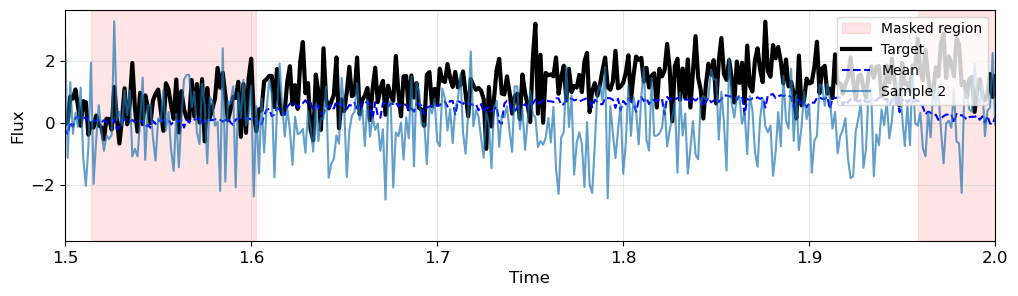

In [16]:

# Plot
fig, ax = plt.subplots(figsize=(12, 3))

    # Shade masked segments
def shade_regions(ax, t, mask_bool):
    n = len(mask_bool)
    if n == 0:
        return
    cur = mask_bool[0]
    start = 0
    labeled_mask = False
    for idx in range(1, n):
        if mask_bool[idx] != cur:
            if cur:
                ax.axvspan(float(t[start]), float(t[idx]), color='red', alpha=0.10, zorder=0, label='Masked region' if not labeled_mask else None)
                labeled_mask = True
            start = idx
            cur = mask_bool[idx]
    if cur:
        ax.axvspan(float(t[start]), float(t[-1]), color='red', alpha=0.10, zorder=0, label='Masked region' if not labeled_mask else None)

shade_regions(ax, timestamps, mask)
ax.plot(timestamps, target, color='k', linewidth=3.0, label='Target')
ax.plot(timestamps, recon_mean, 'b--', linewidth=1.5, label='Mean')

# Reconstruction sample
ax.plot(timestamps, samples[s_idx], alpha=0.7, label=f'Sample {s_idx+1}')

ax.set_xlabel('Time')
ax.set_ylabel('Flux')
ax.legend(loc='upper right', fontsize='small')
ax.grid(True, alpha=0.3)

plt.xlim(1.5,2)
plt.show()